In [1]:
import numpy as np

import h5py as h5

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib import cm

from sam2.addons import show_anns

from PIL import Image

import torch
import torch.nn.functional as F

# ---------------------------
# Device (MPS preferred)
# ---------------------------
def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

DEVICE = get_device()
DTYPE  = torch.float32

import pandas as pd

## Load Data

Each dataset is stored as an `*.h5` file with the following structure:

```text
├── image                 # Original image [x, y], dtype=uint8
├── labels                # Instance label map [x, y], dtype=uint32
├── mask                  # Binary mask of the roving region [x, y], dtype=bool
└── instances/            # Group containing per-instance annotations
    ├── <instance_id>/    # e.g., 0001, 0002, ...
    │   ├── id                    # Integer ID
    │   ├── area                  # Segmented area (float)
    │   ├── bbox                  # Bounding box [x0, y0, w, h]
    │   └── segmentation_cropped  # Cropped mask [w, h], dtype=bool

In [2]:
sample = {}

with h5.File("160_00_01_50x.h5", "r") as file:
    # Load top-level datasets
    sample["image"] = np.array(file["image"])
    sample["labels"] = np.array(file["labels"])
    sample["mask"] = np.array(file["mask"])
    # Load instance information
    instances = []
    if "instances" in file:
        group = file["instances"]
        for key in group.keys():
            inst = group[key]
            instance_dict = {
                "id": int(inst["id"][()]),
                "area": float(inst["area"][()]),
                "bbox": np.array(inst["bbox"]),
                "segmentation_crop": np.array(inst["segmentation_crop"])
            }
            instances.append(instance_dict)
    sample["instances"] = instances

## Display the Data

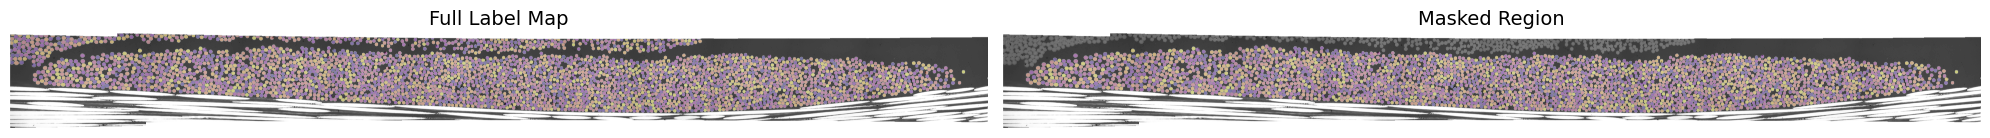

In [3]:
# --- Generate overlays ---
label_map = show_anns(
    instances,
    borders=False,
    alpha=0.35,
    canvas_shape=sample["image"].shape[:2]
)

# Apply mask transparency
masked_rgba = label_map.copy()
m = np.asarray(sample["mask"]).astype(bool)
assert m.shape == masked_rgba.shape[:2]

masked_rgba[~m, :3] = 0.0  # make outside mask transparent

# --- Plot side-by-side ---
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Left: original with all instances
axes[0].imshow(sample["image"], cmap="gray")
axes[0].imshow(label_map)
axes[0].set_title("Full Label Map", fontsize=14)
axes[0].axis("off")

# Right: masked region only
axes[1].imshow(sample["image"], cmap="gray")
axes[1].imshow(masked_rgba)
axes[1].set_title("Masked Region", fontsize=14)
axes[1].axis("off")

plt.tight_layout()

normalized start: 0.4362, 0.5345
normalized start: 0.279, 0.023
(512, 512, 4)


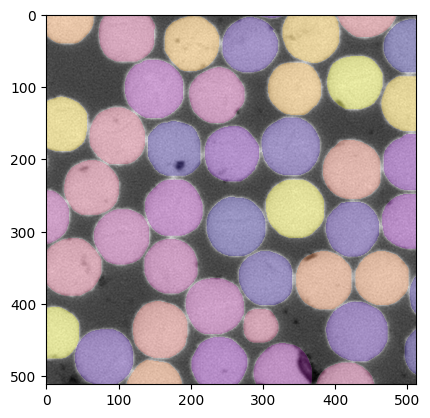

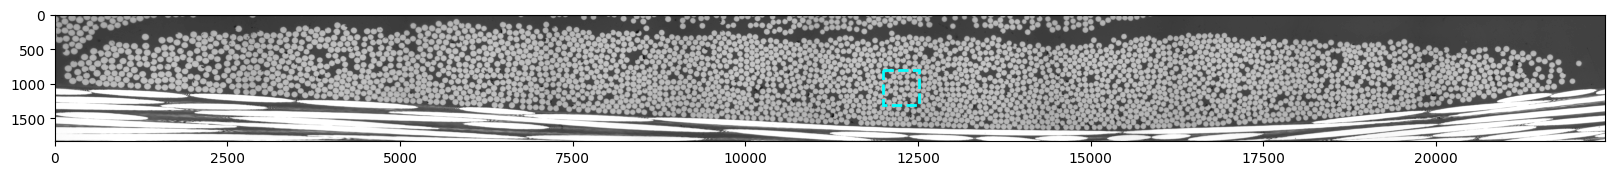

In [4]:
slice_x = slice(200,-200)
slice_y = slice(400,-200)

image = sample["image"][slice_x,slice_y]
masked_rgba_ = masked_rgba[slice_x,slice_y,:]

y, x = 800, 12000   # order matches (row, column)
size = 512

h,w = image.shape

y_norm = y/h
x_norm = x/w

print(f"normalized start: {y_norm:.4f}, {x_norm:.4f}")
print(f"normalized start: {size/h:.3f}, {size/w:.3f}")

patch_ = masked_rgba_[y:y+size, x:x+size, :]
image_ = image[y:y+size, x:x+size]
print(patch_.shape)
plt.figure()

plt.imshow(image_,cmap="gray")
plt.imshow(patch_)

plt.figure(figsize=(20,10))

plt.imshow(image,cmap="gray")
ax = plt.gca()
ax.add_patch(
    Rectangle(
        (x, y),            # (left, top) in pixels
        size, size,        # width, height
        fill=False,
        edgecolor="cyan",
        linewidth=2,
        linestyle="--"
    )
)


im = Image.fromarray((patch_ * 255).astype(np.uint8), mode='RGBA')
im.save("pic_microscale_analysis_roving_b_label.png")

im = Image.fromarray((image_).astype(np.uint8), mode='L')
im.save("pic_microscale_analysis_roving_b_ms.png")

In [5]:
patch_tensor_ = torch.tensor(patch_[..., 3] > 0 ).float().unsqueeze(0)
# patch_tensor_ = (patch_tensor_ > 0 ).float()
print(patch_tensor_.dtype,patch_tensor_.shape)

patch_S2_ = s2_descriptor(patch_tensor_)


plt.imshow(patch_S2_.squeeze(0).numpy(),cmap="plasma")
print(patch_S2_.min(),patch_S2_.max())


# Convert to numpy and normalize to [0,1]
s2_np = patch_S2_.squeeze(0).detach().cpu().numpy()
s2_norm = (s2_np - s2_np.min()) / (s2_np.max() - s2_np.min() + 1e-8)

# Apply colormap
cmap = cm.get_cmap("plasma")
s2_rgba = cmap(s2_norm)  # returns float array (H, W, 4) in 0..1

# Convert to uint8 for PIL
s2_rgba_uint8 = (s2_rgba * 255).astype(np.uint8)

# Save with PIL
im = Image.fromarray(s2_rgba_uint8, mode="RGBA")
im.save("pic_microscale_analysis_roving_c_S2.png")

print("✅ Saved as pic_microscale_analysis_roving_c_S2.png")


torch.float32 torch.Size([1, 512, 512])


NameError: name 's2_descriptor' is not defined

## Analysis

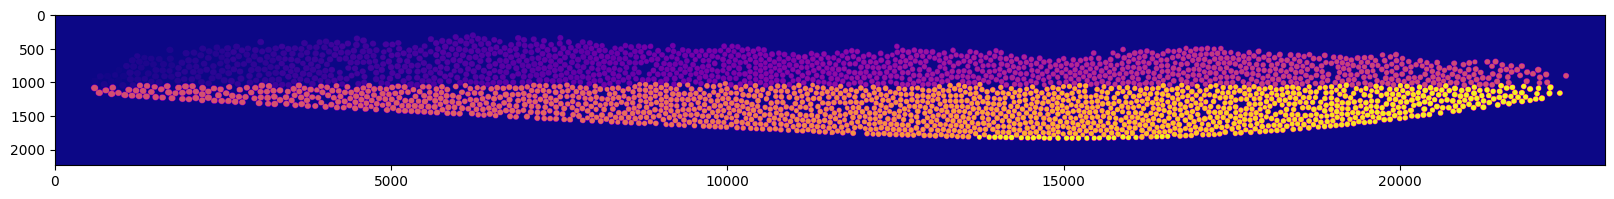

In [5]:
labels = sample["labels"].copy()  # keep original safe


labels[~m] = 0  # set labels outside mask to 0 (or np.nan if float)
plt.figure(figsize=(20,10))
plt.imshow(labels,cmap="plasma")
plt.show()


In [6]:
from skimage.measure import regionprops

len(np.unique(labels))

props = regionprops(labels)
# Each region has an "equivalent_diameter" attribute (in px)
diameters = [r.equivalent_diameter for r in props]

avg_diameter = np.mean(diameters)
print(np.array(diameters).min(),np.array(diameters).max())

print(f"Number of regions: {len(props)}")
print(f"Average equivalent diameter: {avg_diameter:.2f} px")
print(f"Scale based on Average equivalent diameter: {7.0/avg_diameter:.3f} µm/px")

5.641895835477563 120.19754204687337
Number of regions: 2996
Average equivalent diameter: 82.18 px
Scale based on Average equivalent diameter: 0.085 µm/px


In [7]:
len(np.unique(labels))

2997

In [8]:
def patch_torch(input, patch_size, stride, padding="same", device=None):
    """
    Extract square patches from a 2D label map as a tensor [N, patch_size, patch_size].

    Parameters
    ----------
    input : np.ndarray or torch.Tensor
        2D label map (H, W), integer or float values.
    patch_size : int
        Size of the square patch (height = width).
    stride : int
        Step between patch centers.
    padding : str or int, optional
        'same'  → pads evenly so patches cover full image
        'valid' → no padding (only full patches)
        int     → explicit padding value (pixels)
    device : torch.device, optional
        Device to use ('mps', 'cuda', or 'cpu'). Defaults to same as input tensor.

    Returns
    -------
    patches : torch.Tensor
        Tensor of shape [N, patch_size, patch_size].
    coords : list[(y, x)]
        List of top-left pixel coordinates for each patch in the original (unpadded) map.
    padded_shape : (H_padded, W_padded)
        Shape after padding.
    """
    # convert input
    if not isinstance(input, torch.Tensor):
        x = torch.as_tensor(input)
    else:
        x = input
    x = x.to(torch.float32)

    if x.ndim != 2:
        raise ValueError("label_map must be 2D")

    if device is None:
        device = x.device
    x = x.unsqueeze(0).unsqueeze(0).to(device)  # [1,1,H,W]

    H, W = x.shape[-2:]
    p = patch_size

    # Determine padding
    if isinstance(padding, str):
        if padding.lower() == "same":
            pad_h = (stride - (H - p) % stride) % stride if H >= p else (p - H)
            pad_w = (stride - (W - p) % stride) % stride if W >= p else (p - W)
        elif padding.lower() == "valid":
            pad_h = pad_w = 0
        else:
            raise ValueError("padding must be 'same', 'valid', or int")
    else:
        pad_h = pad_w = int(padding)

    # Pad symmetrically (bottom/right if needed)
    x_pad = F.pad(x, (0, pad_w, 0, pad_h), mode="constant", value=0)
    Hp, Wp = x_pad.shape[-2:]

    # Extract patches
    unfold = torch.nn.Unfold(kernel_size=(p, p), stride=stride)
    cols = unfold(x_pad)               # [1, p*p, L]
    L = cols.shape[-1]
    patches = cols.transpose(1, 2).reshape(L, p, p)  # [L, p, p]

    # Compute coordinates of top-left corners
    ys = range(0, Hp - p + 1, stride)
    xs = range(0, Wp - p + 1, stride)
    coords = [(y, x) for y in ys for x in xs]

    return patches, coords, (Hp, Wp)

def filter_patches_by_coverage(patches, coords, min_frac=0.6):
    """
    Keep patches with at least `min_frac` of non-zero labels.

    Parameters
    ----------
    patches : torch.Tensor  # [N, p, p]
        Label patches.
    coords  : list[(y,x)]
        Top-left coords for each patch (same order as `patches`).
    min_frac : float
        Minimum fraction of labeled pixels (labels > 0).

    Returns
    -------
    patches_kept : torch.Tensor   # [K, p, p]
    coords_kept  : list[(y,x)]    # len K
    keep_mask    : torch.BoolTensor  # [N]
    coverage     : torch.Tensor   # [N] fraction per patch (for inspection)
    """
    # fraction of labeled pixels per patch
    coverage = (patches > 0).float().mean(dim=(1, 2))
    keep_mask = coverage >= float(min_frac)

    patches_kept = patches[keep_mask]
    coords_kept  = [c for c, k in zip(coords, keep_mask.tolist()) if k]
    return patches_kept, coords_kept, keep_mask, coverage


from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection

def plot_patch_bboxes(image, coords, patch_size, color="lime", lw=1.5, alpha=0.9):
    """
    Draw bounding boxes for kept patches on top of the original image.

    Parameters
    ----------
    image : np.ndarray
        Original image (H, W) or (H, W, 3).
    coords : list[(y, x)]
        Top-left coordinates for each kept patch (from extract/filter step).
    patch_size : int
        Square patch size used when extracting patches.
    color : str
        Edge color of rectangles.
    lw : float
        Line width.
    alpha : float
        Alpha of rectangle edges.
    """
    H, W = image.shape[:2]
    rects = []

    for (y, x) in coords:
        x0 = max(0, min(W, x))
        y0 = max(0, min(H, y))
        x1 = max(0, min(W, x + patch_size))
        y1 = max(0, min(H, y + patch_size))
        if x1 <= x0 or y1 <= y0:   # fully outside after clipping
            continue
        rects.append(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False))

    fig, ax = plt.subplots(figsize=(20, 10))
    if image.ndim == 2:
        ax.imshow(image, cmap="gray")
    else:
        ax.imshow(image)
    if rects:
        pc = PatchCollection(rects, facecolor="none", edgecolor=color, linewidths=lw, alpha=alpha)
        ax.add_collection(pc)
    ax.set_title(f"Kept patches: {len(rects)}")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

Kept 331 / 623 patches


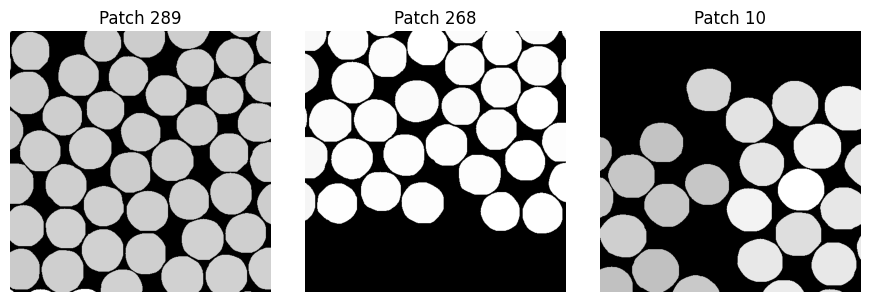

In [11]:
size = 512
stride = size//2

patches, coords, padded_shape = patch_torch(
    labels, patch_size=size, stride=stride, padding="valid", device="mps"
)

patches_kept, coords_kept, keep_mask, coverage = filter_patches_by_coverage(patches, coords, min_frac=0.4)

print(f"Kept {len(patches_kept)} / {len(patches)} patches")

fig, axs = plt.subplots(1,3,figsize=(3*3,3))

for i in range(3):
    # pick a random patch index
    i_random = np.random.randint(0, len(patches_kept))

    axs[i].imshow(patches_kept[i_random].cpu().numpy(), cmap="gray")
    axs[i].set_title(f"Patch {i_random}")
    axs[i].axis("off")

plt.tight_layout()
plt.show()

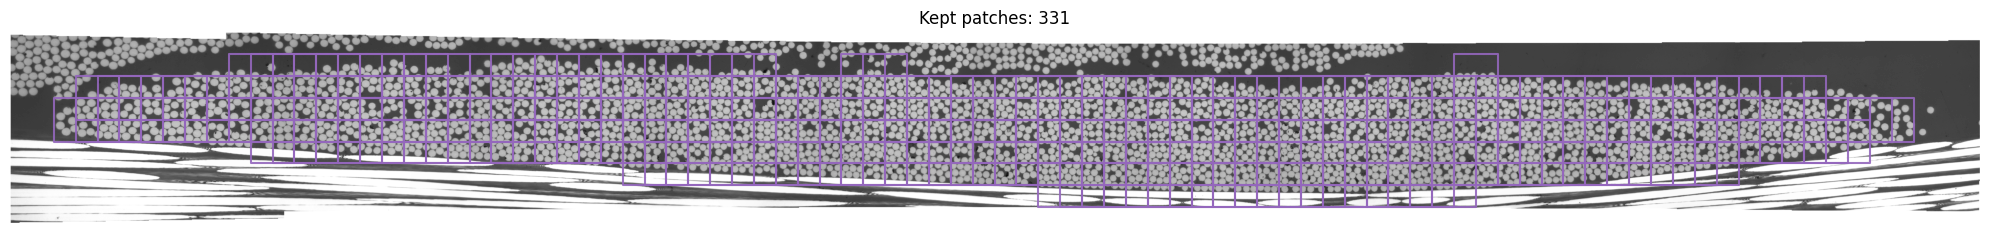

In [12]:
plot_patch_bboxes(sample["image"], coords_kept, patch_size=size, color="tab:purple", lw=1.5)

## Spatial Estimation of the statistical RVE size

## Helper Functions for Analysis


Using descriptors for estimation of 




In [ ]:
@torch.no_grad()
def s2_descriptor(patches: torch.Tensor, radial: bool = False, eps: float = 1e-12):
    """
    Compute two-point correlation S2 for binary patches.

    Parameters
    ----------
    patches : torch.Tensor
        Shape [B, H, W], values in {0,1} (float/bool is fine). On CPU/GPU/MPS.

    Returns
    -------
    result : dict
        - 'S2':   (B,H,W)      centered two-point correlation
    """
    assert patches.ndim == 3, "Expected [B,H,W]"
    x = patches.to(torch.float32)

    B, H, W = x.shape


    # ---- S2 via FFT (autocorrelation normalized by N) ----
    F = torch.fft.fft2(x, dim=(-2, -1))
    S2 = torch.real(torch.fft.ifft2(F * torch.conj(F), dim=(-2, -1))) / (H * W)
    S2 = torch.fft.fftshift(S2, dim=(-2, -1))  # center
    
    if radial:
        # Precompute radius bins (shared for batch)
        device = x.device
        y = torch.arange(H, device=device)
        z = torch.arange(W, device=device)
        yy, zz = torch.meshgrid(y, z, indexing="ij")
        cy, cz = (H - 1) / 2.0, (W - 1) / 2.0
        r = torch.sqrt((yy - cy) ** 2 + (zz - cz) ** 2)
        r_int = r.round().to(torch.int64)
        rmax = int(r_int.max().item())

        vals = S2.reshape(B, -1)
        bins = r_int.reshape(-1)
        prof = torch.zeros((B, rmax + 1), device=device, dtype=vals.dtype)
        prof.scatter_add_(1, bins.unsqueeze(0).expand(B, -1), vals)

        # counts per radius
        cnt = torch.zeros(rmax + 1, device=device, dtype=vals.dtype)
        cnt.scatter_add_(0, bins, torch.ones_like(bins, dtype=vals.dtype, device=device))
        prof = prof / torch.clamp(cnt, min=eps)

        return S2, prof  # (B, R)
    
    return S2


@torch.no_grad()
def phi_descriptor(patches: torch.Tensor):
    """
    Compute volume fraction (phi) for binary patches.

    Parameters
    ----------
    patches : torch.Tensor
        Shape [B, H, W], values in {0,1} (float/bool is fine). On CPU/GPU/MPS.
    Returns
    -------
    result : dict
        - 'phi':  (B,)         volume fraction
    """
    assert patches.ndim == 3, "Expected [B,H,W]"
    x = patches.to(torch.float32)

    B, H, W = x.shape

    # ---- phi ----
    phi = x.mean(dim=(1, 2))  # (B,)
    return phi


@torch.no_grad()
def corr_length_halfheight(S2r: torch.Tensor, phi: torch.Tensor) -> torch.Tensor:
    """
    Half-height correlation length per patch.
    S2r: [B, R], phi: [B] in [0,1]
    Returns: zeta [B] (int64), first r where C(r) <= 0.5*C(0); R-1 if never drops.
    """
    B, R = S2r.shape
    base = (phi ** 2).unsqueeze(1)              # [B,1]
    C = S2r - base                               # [B,R]
    C0 = C[:, :1].clamp_min(1e-12)               # [B,1], guard
    cond = C <= 0.5 * C0                         # [B,R] bool
    # first index where condition is True; if none True, use R-1
    idx = torch.where(cond.any(dim=1),
                      torch.argmax(cond.to(torch.int32), dim=1),
                      torch.full((B,), R-1, device=S2r.device, dtype=torch.int64))
    return idx

@torch.no_grad()
def integral_range_from_S2r(S2r: torch.Tensor, phi: torch.Tensor) -> torch.Tensor:
    """
    Same as before, batched. Returns A_int [B] in pixel^2.
    """
    B, R = S2r.shape
    base = (phi ** 2).unsqueeze(1)
    C = S2r - base
    Cpos = torch.clamp(C, min=0.0)
    r = torch.arange(R, device=S2r.device, dtype=S2r.dtype)  # [R]
    return (2.0 * torch.pi * (Cpos * r).sum(dim=1))          # [B]

@torch.no_grad()
def rve_size_from_integral_range(phi_mean: torch.Tensor, A_int_mean: torch.Tensor, cv_target: float) -> torch.Tensor:
    return torch.sqrt((phi_mean * (1.0 - phi_mean)) * A_int_mean / (cv_target ** 2))

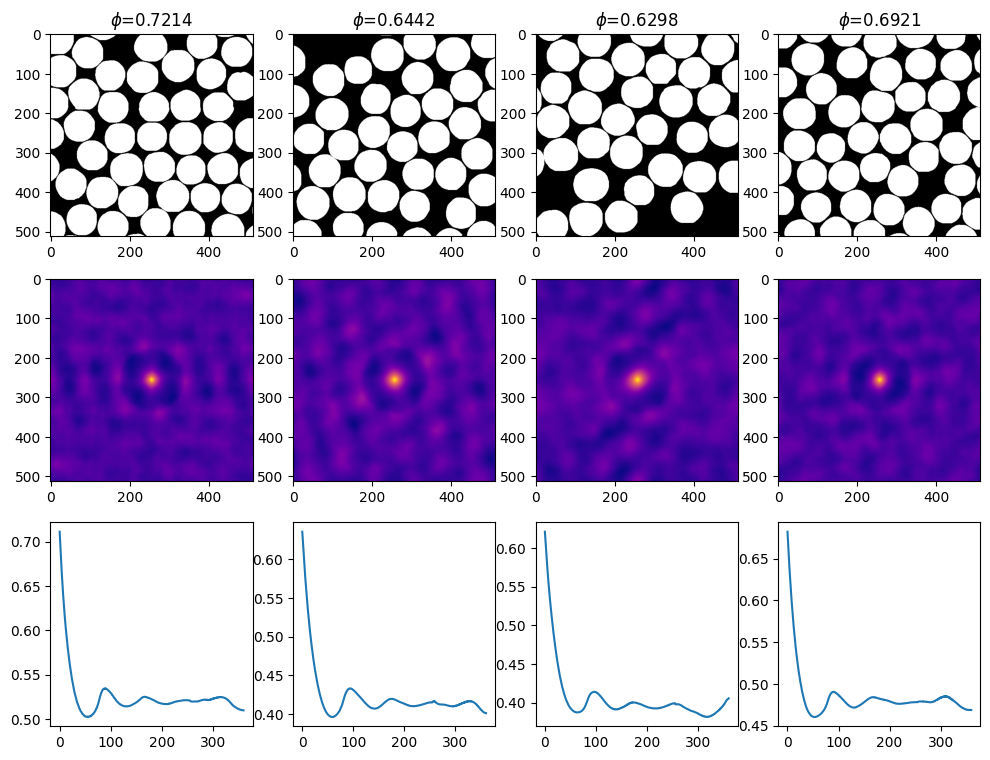

In [14]:
patches_tensor = (patches_kept > 0).float() # binary as float


patches_S2, patches_S2r = s2_descriptor(patches_tensor,radial=True)
patches_phi = phi_descriptor(patches_tensor)


fig, axs = plt.subplots(3,4, figsize=(4*3,3*3))

for i in range(4):
    i_random = np.random.randint(0, len(patches_tensor))
    axs[0][i].imshow(patches_tensor[i_random,::].cpu().numpy(),cmap="gray")
    axs[0][i].set_title(f"$\phi$={patches_phi[i_random].cpu().numpy():.4f}")
    axs[1][i].imshow(patches_S2[i_random,::].cpu().numpy(),cmap="plasma")
    axs[2][i].plot(patches_S2r[i_random,1:].cpu().numpy())


In [28]:
cv_target = 0.05
out = {}
S2r_list = []
sizes = [512+128]

with torch.no_grad():
    for wh in sizes:
        print(f"Processing patch size {wh}")
        patches, coords, _ = patch_torch(labels, patch_size=int(wh), stride=int(wh//2),
                                         padding="valid", device="mps")

        patches_kept, coords_kept, keep_mask, coverage = filter_patches_by_coverage(
            patches, coords, min_frac=0.6
        )
        if patches_kept.numel() == 0:
            print(f"⚠️  No valid patches at size {wh}, skipping.")
            continue
        print(patches_kept.shape)
        patches_bin = (patches_kept > 0).to(torch.float32)

        # S2(r) and phi
        S2, pathces_S2r = s2_descriptor(patches_bin, radial=True)  # returns (B, R)
        patches_phi = phi_descriptor(patches_bin)          # returns (B,)

        S2r_list.append(patches_S2r.cpu().numpy())

        # Correlation length per patch (half-height)
        zeta = corr_length_halfheight(patches_S2r, patches_phi)  # [B]
        zeta_min = int(zeta.min().item())
        zeta_mean = float(zeta.to(torch.float32).mean().item())

        # Integral range + predicted RVE
        A_int = integral_range_from_S2r(patches_S2r, patches_phi)     # [B]
        L_pred = rve_size_from_integral_range(patches_phi.mean(), A_int.mean(), cv_target=cv_target)

        # Empirical stability (CV of phi)
        cv_phi = (
            (patches_phi.std(unbiased=True) / patches_phi.mean()).item()
            if patches_phi.numel() > 1 and patches_phi.mean() > 0
            else 0.0
        )

        out[int(wh)] = {
            "n_patches": int(patches_bin.shape[0]),
            "cv_phi": float(cv_phi),
            "mu_phi": float(patches_phi.mean().item()),
            "mu_Aint": float(A_int.mean().item()),
            "L_pred_from_cov": float(L_pred.item()),
            "zeta_min": zeta_min,                  # ⟵ minimum correlation length (pixels)
            "zeta_mean": zeta_mean,                # (optional) mean correlation length
        }

# Summary
empirical = next((wh for wh in sorted(out) if out[wh]["cv_phi"] <= cv_target), None)
theory_L = max(out, key=lambda w: out[w]["L_pred_from_cov"]) if out else None

print("\n--- RVE Summary ---")
print(f"Empirical RVE (first size with CV(phi) ≤ {cv_target*100:.1f}%): {empirical}")
print(f"Theoretical RVE (largest predicted L from covariance): {theory_L}")

print("\nDetails per patch size:")
for wh, s in out.items():
    print(
        f"{wh:4d} | n={s['n_patches']:4d} "
        f"| μφ={s['mu_phi']:.3f} | CV(φ)={s['cv_phi']:.3f} "
        f"| μAint={s['mu_Aint']:.2f} | L_pred={s['L_pred_from_cov']:.1f}px "
        f"| ζ_min={s['zeta_min']}px | ζ_mean={s['zeta_mean']:.1f}px"
    )

Processing patch size 640
torch.Size([128, 640, 640])


RuntimeError: The size of tensor a (230) must match the size of tensor b (128) at non-singleton dimension 0

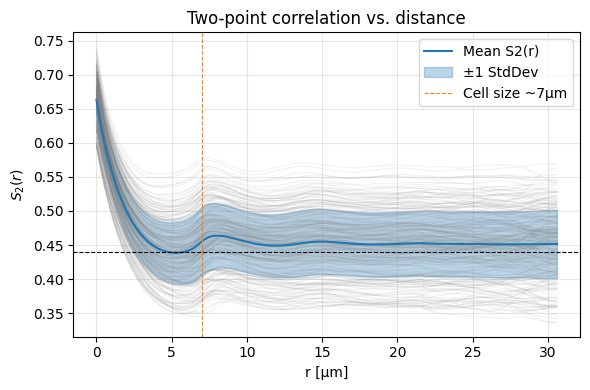

In [95]:
fig, ax = plt.subplots(figsize=(6,4))
dict = {}
for S2r in S2r_list[-1:]:

    s2r_mean = S2r.mean(axis=0)
    s2r_std = S2r.std(axis=0)
    phi_mean = S2r.mean(axis=0)[1]
    r = np.arange(len(s2r_mean[1:]))*0.085
    dict["r"] = r
    for i , s2r in enumerate(S2r):
        ax.plot(r,s2r[1:], color="tab:gray", alpha=0.1, lw=0.8)
        dict[f"S2r_{i}"] = s2r[1:]


    ax.plot(r,s2r_mean[1:], label="Mean S2(r)", color="tab:blue")
    ax.fill_between(
        r,
        s2r_mean[1:] - s2r_std[1:],
        s2r_mean[1:] + s2r_std[1:],
        color="tab:blue",
        alpha=0.3,
        label="±1 StdDev"
    )
    ax.axhline(phi_mean**2, color="k", ls="--", lw=0.8)
    ax.axvline(7.0, color="tab:orange", ls="--", lw=0.8, label="Cell size ~7µm")

    pd.DataFrame({"r_um":r,
                  "r_Px":np.arange(len(s2r_mean[1:])),
                  "S2r":s2r_mean[1:],
                  "S2r_std":s2r_std[1:]
                  }
                  ).to_csv("160_00_01_50x_512_S2r_stats.csv",index=False)
    pd.DataFrame(dict).to_csv("160_00_01_50x_512_S2r.csv",index=False)

ax.set_xlabel("r [µm]")
ax.set_ylabel(r"$S_2(r)$")
ax.set_title("Two-point correlation vs. distance")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



